# Séries Temporais — Benchmarks e Métricas de Performance

## Objetivos da aula

Neste notebook vamos integrar os conteúdos de **modelos benchmark** e **métricas de avaliação de previsões**.

Ao final, o aluno deverá ser capaz de:

- compreender o papel de um **benchmark (baseline)** em previsão de séries temporais;
- diferenciar previsões ingênuas de modelos que utilizam características da série;
- aplicar benchmarks de **média, último valor, sazonalidade, drift e média móvel**;
- separar uma série temporal em **treino e teste**, respeitando a ordem temporal;
- gerar previsões para um horizonte de teste comum;
- calcular e interpretar métricas de desempenho;
- comparar modelos em uma mesma tabela;
- compreender por que um modelo sofisticado só é útil se superar um benchmark adequado.

## 1. O que é um benchmark em séries temporais?

Um **benchmark** é um método simples usado como referência para avaliar modelos de previsão.

A ideia é responder a uma pergunta fundamental:

> **Um modelo mais complexo realmente consegue prever melhor do que uma estratégia simples?**

Em séries temporais, alguns benchmarks são particularmente importantes:

- **Naive / último valor:** a próxima observação é igual à última observação conhecida;
- **Naive Mean:** todas as previsões são iguais à média histórica;
- **Naive Seasonal:** a previsão repete o valor observado na mesma posição do ciclo anterior;
- **Naive Drift:** utiliza uma extrapolação linear baseada na variação média entre o primeiro e o último valor;
- **Naive Moving Average:** utiliza uma média das observações mais recentes.

O benchmark não é um "modelo ruim". Ele é uma **referência estatística**. Em muitos problemas reais, uma técnica sofisticada que não supera um benchmark simples não está agregando valor preditivo suficiente.

## 2. Por que o benchmark deve ser avaliado no conjunto de teste?

Não devemos comparar modelos utilizando apenas os dados usados para ajustar o modelo.

A avaliação deve reproduzir, tanto quanto possível, a situação real de previsão:

**passado → treinamento → futuro não observado → previsão → comparação com o realizado**

Em séries temporais, a divisão deve respeitar a ordem cronológica. Não fazemos uma divisão aleatória como em muitos problemas tradicionais de aprendizado supervisionado.

Neste notebook, vamos utilizar uma parte inicial da série para treinamento e reservar as observações finais para teste.

In [56]:
#%pip install -q darts
#%pip install "numpy<2"

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from darts.datasets import AirPassengersDataset
from darts import TimeSeries
from darts.models import (
    NaiveDrift,
    NaiveMean,
    NaiveSeasonal,
    NaiveMovingAverage
)

from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (12, 5)

# 3. Exemplo principal: passageiros de avião

Vamos utilizar o conjunto **AirPassengers**, uma série mensal clássica de passageiros aéreos.

Antes de escolher um benchmark, é importante observar a série.

Perguntas para os alunos:

1. Existe tendência?
2. Existe sazonalidade?
3. A amplitude da sazonalidade parece constante?
4. A variabilidade aumenta ao longo do tempo?
5. Qual benchmark você espera que seja mais competitivo?

In [58]:
series = AirPassengersDataset().load()

series

,#Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0
...,...
1960-08-01,606.0
1960-09-01,508.0
1960-10-01,461.0


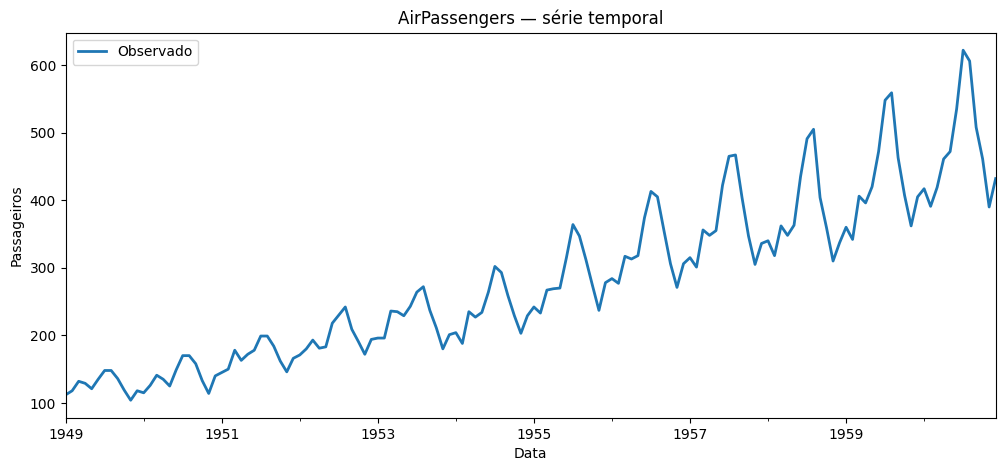

In [59]:
series.plot(label="Observado")
plt.title("AirPassengers — série temporal")
plt.xlabel("Data")
plt.ylabel("Passageiros")
plt.legend()
plt.show()

## 4. Separação treino e teste

Vamos reservar os últimos **24 meses** para avaliação.

A escolha de um horizonte de teste deve estar relacionada ao problema. Aqui utilizamos 24 meses porque a série possui sazonalidade anual e queremos observar mais de um ciclo sazonal.

**Importante:** o conjunto de teste não participa do ajuste dos benchmarks.

In [60]:
horizon = 24

train, test = series[:-horizon], series[-horizon:]

print("Treino:", train.start_time(), "até", train.end_time())
print("Teste :", test.start_time(), "até", test.end_time())
print("Horizonte de previsão:", len(test))

Treino: 1949-01-01 00:00:00 até 1958-12-01 00:00:00
Teste : 1959-01-01 00:00:00 até 1960-12-01 00:00:00
Horizonte de previsão: 24


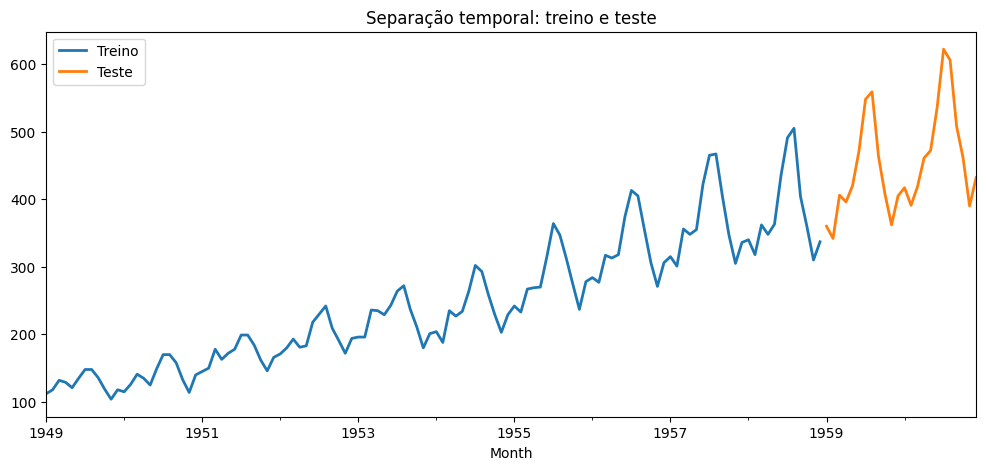

In [61]:
train.plot(label="Treino")
test.plot(label="Teste")
plt.title("Separação temporal: treino e teste")
plt.legend()
plt.show()

# 5. Benchmark 1 — Naive Mean

O **Naive Mean** prevê, para todos os períodos futuros, a média das observações disponíveis no treinamento.


### Interpretação

É um benchmark extremamente simples. Ele pode ser útil quando não há uma estrutura temporal forte ou quando queremos estabelecer uma referência inicial.

Entretanto, para séries com tendência ou sazonalidade pronunciada, esperamos que outros benchmarks sejam superiores.

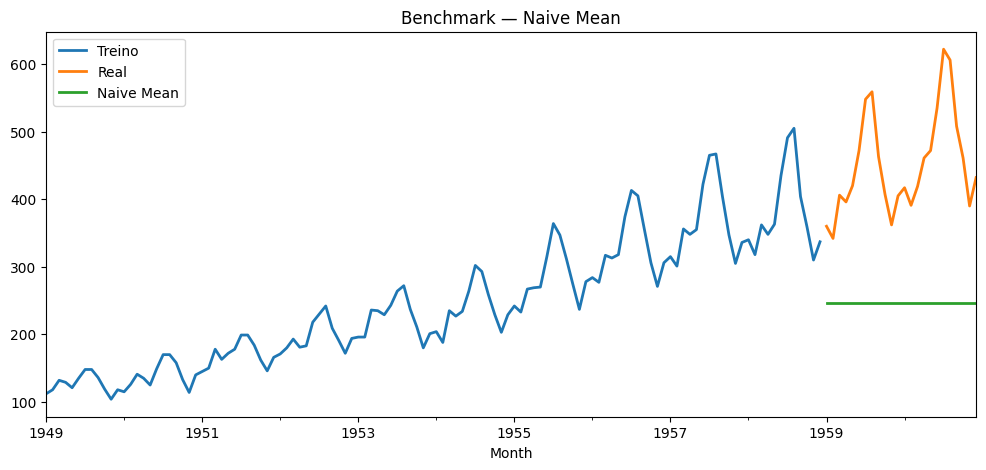

In [62]:
model_naive_mean = NaiveMean()
model_naive_mean.fit(train)
pred_naive_mean = model_naive_mean.predict(len(test))

train.plot(label="Treino")
test.plot(label="Real")
pred_naive_mean.plot(label="Naive Mean")
plt.title("Benchmark — Naive Mean")
plt.legend()
plt.show()

# 6. Benchmark 2 — Naive / último valor

O benchmark mais simples de persistência considera que o próximo valor será igual ao último valor observado.


Para múltiplos passos à frente, a previsão permanece constante.

Esse benchmark é particularmente importante porque, em algumas séries, o valor mais recente contém muita informação sobre o futuro imediato.

In [63]:
last_value = train.last_value()

pred_naive_last = pd.Series(
    np.repeat(last_value, len(test)),
    index=pd.DatetimeIndex(test.time_index)
)

print("Último valor observado no treino:", last_value)

Último valor observado no treino: 337.0


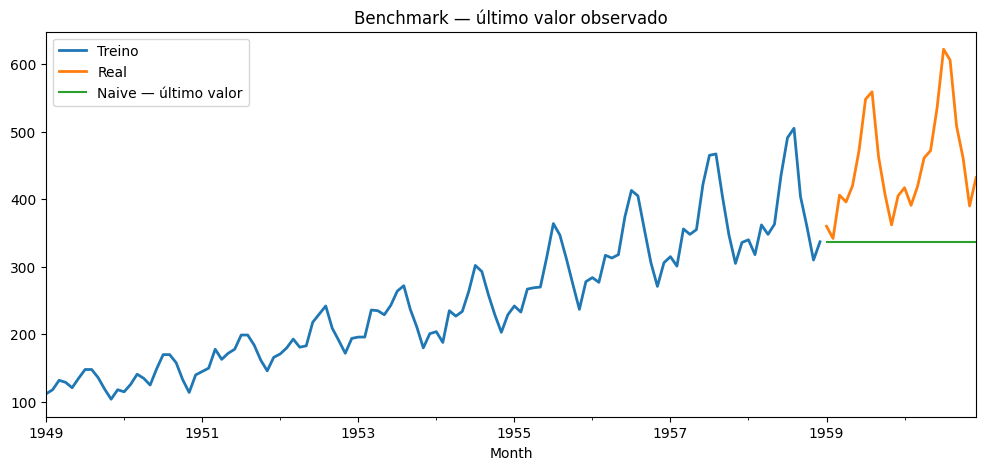

In [64]:
train.plot(label="Treino")
test.plot(label="Real")
pred_naive_last.plot(label="Naive — último valor")
plt.title("Benchmark — último valor observado")
plt.legend()
plt.show()

# 7. Benchmark 3 — Naive Seasonal

Quando existe sazonalidade, podemos repetir o valor observado no mesmo período do ciclo anterior.



Esse benchmark é particularmente importante para séries sazonais. Ele não ignora a estrutura temporal: utiliza explicitamente o ciclo sazonal.

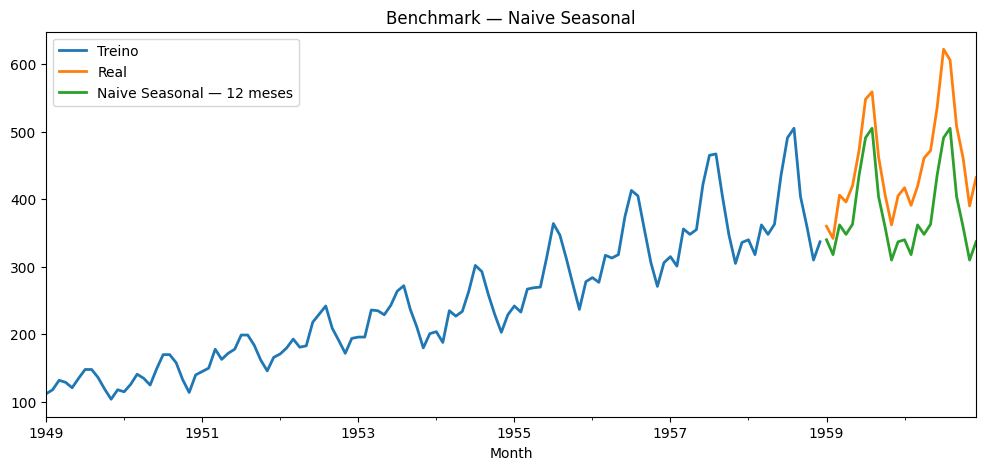

In [65]:
seasonal_period = 12

model_naive_seasonal = NaiveSeasonal(K=seasonal_period)
model_naive_seasonal.fit(train)
pred_naive_seasonal = model_naive_seasonal.predict(len(test))

train.plot(label="Treino")
test.plot(label="Real")
pred_naive_seasonal.plot(label="Naive Seasonal — 12 meses")
plt.title("Benchmark — Naive Seasonal")
plt.legend()
plt.show()

# 8. Benchmark 4 — Naive Drift

O **Naive Drift** extrapola a variação média observada entre o primeiro e o último ponto da série de treinamento.


Assim, diferentemente do Naive simples, a previsão não permanece necessariamente constante.

Esse benchmark é interessante quando existe uma tendência aproximadamente linear.

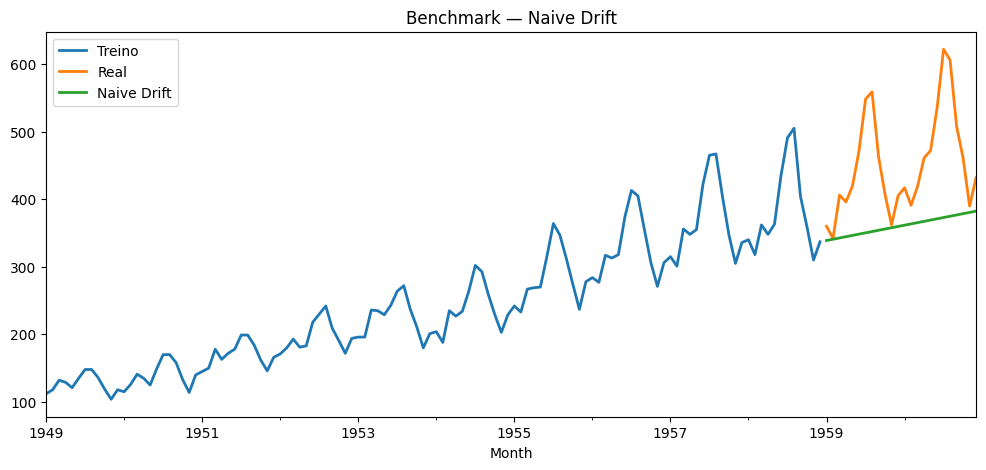

In [66]:
model_naive_drift = NaiveDrift()
model_naive_drift.fit(train)
pred_naive_drift = model_naive_drift.predict(len(test))

train.plot(label="Treino")
test.plot(label="Real")
pred_naive_drift.plot(label="Naive Drift")
plt.title("Benchmark — Naive Drift")
plt.legend()
plt.show()

# 9. Benchmark 5 — Naive Moving Average

A média móvel utiliza as observações mais recentes para produzir a previsão.


onde \(k\) representa o tamanho da janela.

Vamos utilizar uma janela de **12 meses**, permitindo uma comparação com o ciclo anual da série.

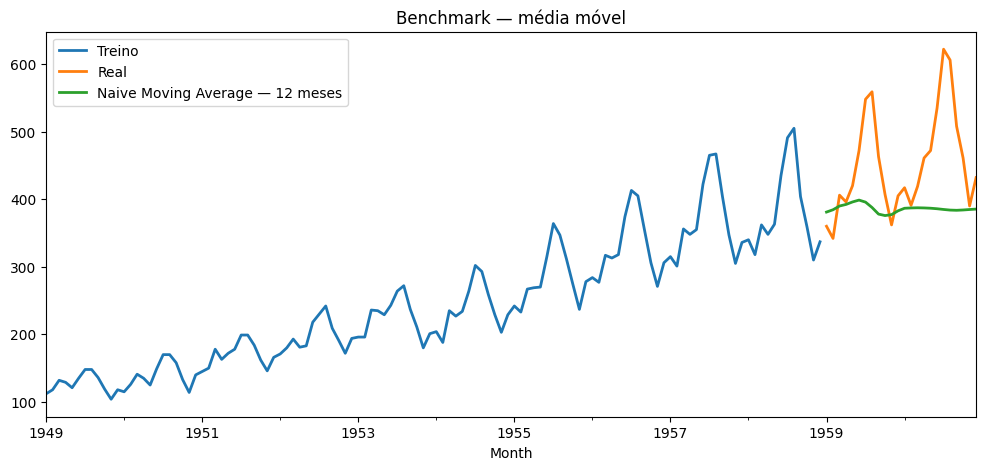

In [67]:
window = 12

model_naive_ma = NaiveMovingAverage(input_chunk_length=window)
model_naive_ma.fit(train)
pred_naive_ma = model_naive_ma.predict(len(test))

train.plot(label="Treino")
test.plot(label="Real")
pred_naive_ma.plot(label="Naive Moving Average — 12 meses")
plt.title("Benchmark — média móvel")
plt.legend()
plt.show()

# 10. Métricas de performance

Uma previsão não deve ser avaliada apenas visualmente.

Precisamos transformar os erros de previsão em medidas quantitativas.

Para **todos os benchmarks**, calcularemos as mesmas métricas. Isso é essencial para que a comparação seja justa.

### MAE — Mean Absolute Error

Mede o erro absoluto médio:

$$MAE = \frac{1}{n}\sum_{t=1}^{n}|y_t-\hat y_t|$$

É fácil de interpretar e está na mesma unidade das vendas.

### MSE — Mean Squared Error

$$MSE = \frac{1}{n}\sum_{t=1}^{n}(y_t-\hat y_t)^2$$

Penaliza mais fortemente erros grandes.

### RMSE — Root Mean Squared Error

$$RMSE = \sqrt{MSE}$$

Também está na unidade da variável de interesse, mas mantém a maior sensibilidade a erros grandes.

### MAPE — Mean Absolute Percentage Error

$$MAPE = \frac{100}{n}\sum_{t=1}^{n}\left|\frac{y_t-\hat y_t}{y_t}\right|$$

Expressa o erro em termos percentuais. **Cuidado:** valores observados iguais a zero tornam essa métrica problemática.

### MPE — Mean Percentage Error

Mantém o sinal do erro percentual e, portanto, ajuda a identificar viés sistemático de superestimação ou subestimação.

### OPE — Overall Percentage Error

Compara o erro acumulado de previsão com o total observado. É particularmente útil para interpretar o impacto agregado do erro no volume total de vendas.

Para MAE, MSE, RMSE, MAPE e OPE, **menor é melhor**. Para MPE, o ideal é um valor próximo de zero, pois o sinal indica direção do viés.

In [68]:
def mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))


def mse(actual, predicted):
    return np.mean((actual - predicted) ** 2)


def rmse(actual, predicted):
    return np.sqrt(mse(actual, predicted))


def mape(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100


def mpe(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    mask = actual != 0
    return np.mean((actual[mask] - predicted[mask]) / actual[mask]) * 100


def ope(actual, predicted):
    return ((np.sum(predicted) - np.sum(actual)) / np.sum(actual)) * 100

## 11. Atenção à interpretação das métricas

Não existe uma métrica universalmente melhor.

- **MAE:** fácil de interpretar e menos sensível a grandes erros do que MSE/RMSE.
- **RMSE:** útil quando grandes erros devem receber uma penalização maior.
- **MAPE:** facilita a comunicação percentual, mas não deve ser usado cegamente quando existem zeros.
- **MPE:** ajuda a identificar viés de previsão.
- **OPE:** avalia especificamente o erro acumulado do total previsto.

Além disso, métricas devem ser comparadas **no mesmo conjunto de teste e no mesmo horizonte de previsão**.

In [69]:
#def to_numpy(ts):
#    return ts.values().flatten()
#y_test = to_numpy(test)


def to_numpy(ts):
    if hasattr(ts, "to_numpy"):
        return ts.to_numpy().flatten()
    elif hasattr(ts, "values"):
        # Trata casos em que .values é método (Darts) ou propriedade (Pandas)
        v = ts.values() if callable(ts.values) else ts.values
        return v.flatten()
    return ts.flatten()

y_test = to_numpy(test)

predictions = {
    "Naive Mean": to_numpy(pred_naive_mean),
    "Naive Último Valor": to_numpy(pred_naive_last),
    "Naive Seasonal": to_numpy(pred_naive_seasonal),
    "Naive Drift": to_numpy(pred_naive_drift),
    "Naive Moving Average": to_numpy(pred_naive_ma),
}

resultados = []

for modelo, pred in predictions.items():
    resultados.append({
        "Modelo": modelo,
        "MAE": mae(y_test, pred),
        "MSE": mse(y_test, pred),
        "RMSE": rmse(y_test, pred),
        "MAPE (%)": mape(y_test, pred),
        "MPE (%)": mpe(y_test, pred),
        "OPE (%)": ope(y_test, pred),
    })

metricas_benchmarks = (
    pd.DataFrame(resultados)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

metricas_benchmarks

,Modelo,MAE,MSE,RMSE,MAPE (%),MPE (%),OPE (%)
0,Naive Seasonal,71.250000,5928.166667,76.994589,15.523355,15.523355,-15.754561
1,Naive Moving Average,72.677490,9831.845935,99.155665,14.349637,12.479725,-14.621303
2,Naive Drift,91.615546,13387.299308,115.703497,18.408358,18.408358,-20.257722
3,Naive Último Valor,115.250000,18859.250000,137.328985,23.577467,23.577467,-25.483693
4,Naive Mean,206.341667,48153.570903,219.439219,44.234606,44.234606,-45.625576


# 12. Comparação visual de todos os benchmarks

Uma tabela de métricas mostra o desempenho quantitativo. O gráfico ajuda a entender **por que** os modelos apresentaram determinado desempenho.

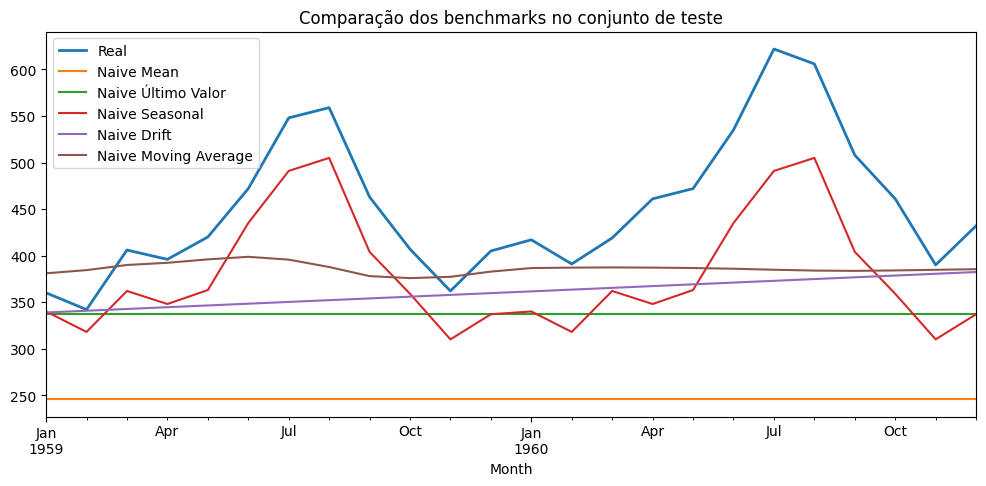

In [70]:
test.plot(label="Real")

for nome, pred in predictions.items():
    pd.Series(pred, index=pd.DatetimeIndex(test.time_index)).plot(label=nome)

plt.title("Comparação dos benchmarks no conjunto de teste")
plt.legend()
plt.show()

# 13. Como escolher o melhor benchmark?

Para métricas de erro como MAE, MSE, RMSE e MAPE:

> **quanto menor, melhor.**

Para MPE e OPE, a interpretação é diferente porque existe direção do erro.

Um MPE próximo de zero pode indicar pouco viés médio, mas isso **não significa necessariamente que o modelo tenha os menores erros absolutos**.

Por isso, devemos combinar:

1. análise das métricas;
2. análise gráfica;
3. conhecimento do problema;
4. comportamento do erro;
5. horizonte de previsão.

O benchmark escolhido deve ser uma referência plausível para o problema, e não simplesmente o método que apresenta o menor valor em uma única métrica.

# 14. Exemplo adicional — série sintética com tendência

Vamos criar uma série simples com tendência e ruído.

Esse exemplo ajuda a visualizar uma situação em que um benchmark que incorpora tendência pode ser mais adequado que uma previsão constante.

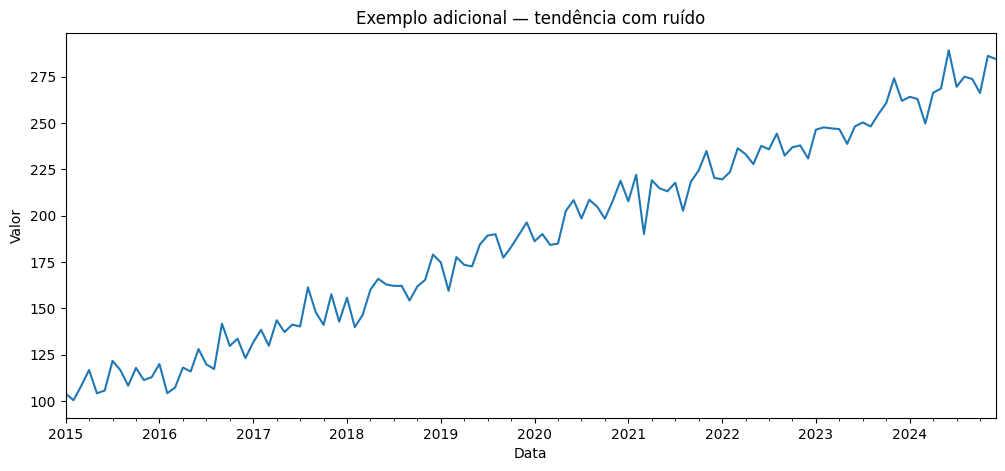

In [71]:
np.random.seed(42)

n = 120
datas = pd.date_range("2015-01-01", periods=n, freq="MS")

t = np.arange(n)
y_tendencia = 100 + 1.5 * t + np.random.normal(0, 8, n)

serie_tendencia = pd.Series(y_tendencia, index=datas)

serie_tendencia.plot()
plt.title("Exemplo adicional — tendência com ruído")
plt.xlabel("Data")
plt.ylabel("Valor")
plt.show()

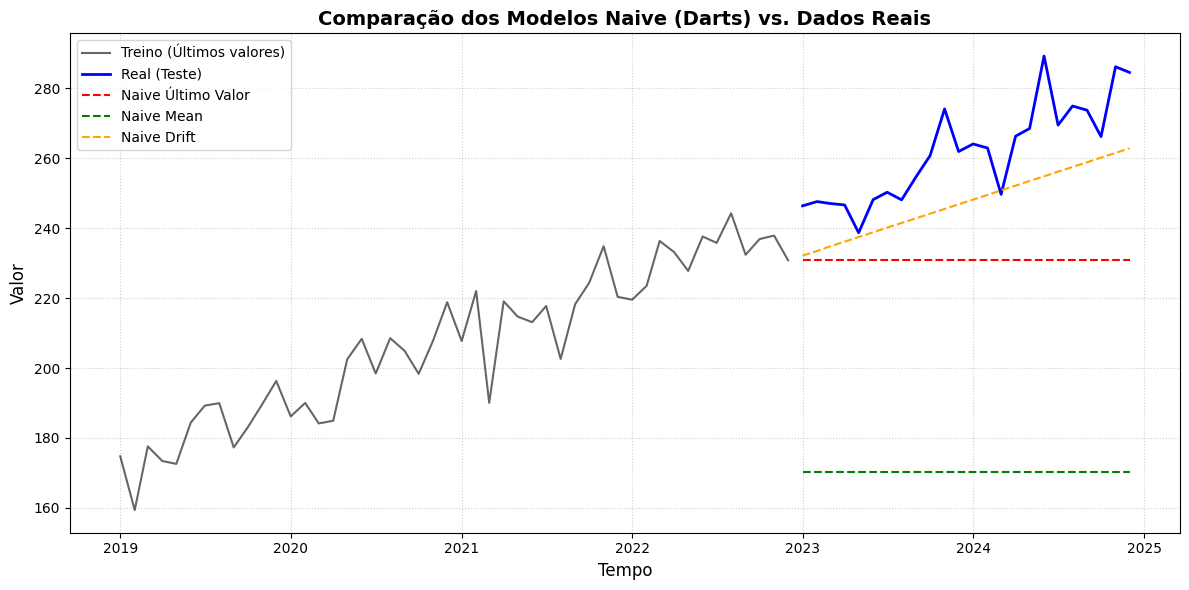

,Modelo,MAE,MSE,RMSE,MAPE (%),MPE (%),OPE (%)
0,Naive Drift,14.272705,259.100909,16.096612,5.354110,5.315190,-5.417666
1,Naive Último Valor,30.862142,1144.266699,33.827011,11.550823,11.550823,-11.795019
2,Naive Mean,91.296718,8526.885699,92.341138,34.711900,34.711900,-34.892152


In [72]:
# 1. Garante que a série esteja no formato TimeSeries do Darts
if not isinstance(serie_tendencia, TimeSeries):
    series = TimeSeries.from_series(serie_tendencia)
else:
    series = serie_tendencia

# 2. Divisão em Treino e Teste
h = 24
train_t, test_t = series[:-h], series[-h:]

# 3. Definição e Ajuste dos Modelos
modelos = {
    "Naive Último Valor": NaiveSeasonal(K=1),
    "Naive Mean": NaiveMean(),
    "Naive Drift": NaiveDrift(),
}

preds_tendencia = {}

# 4. Treinamento e Predição
for nome, modelo in modelos.items():
    modelo.fit(train_t)
    # Guarda o vetor 1D do NumPy para plotagem e métricas
    preds_tendencia[nome] = modelo.predict(h).values().flatten()

# 5. Extração dos vetores e datas (padrão Darts)
y_test_array = test_t.values().flatten()
y_train_array = train_t.values().flatten()

index_treino = train_t.time_index
index_teste = test_t.time_index

# 6. Gráfico Comparativo
plt.figure(figsize=(12, 6))

# Plot dos dados reais (treino recente e teste)
plt.plot(index_treino[-48:], y_train_array[-48:], label="Treino (Últimos valores)", color="black", alpha=0.6)
plt.plot(index_teste, y_test_array, label="Real (Teste)", color="blue", linewidth=2)

# Plot automatizado das previsões a partir do dicionário
estilos = {"Naive Último Valor": "red", "Naive Mean": "green", "Naive Drift": "orange"}
for nome, pred in preds_tendencia.items():
    plt.plot(index_teste, pred, label=nome, linestyle="--", color=estilos.get(nome, "gray"))

# Configurações do gráfico
plt.title("Comparação dos Modelos Naive (Darts) vs. Dados Reais", fontsize=14, fontweight="bold")
plt.xlabel("Tempo", fontsize=12)
plt.ylabel("Valor", fontsize=12)
plt.legend(loc="best")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

plt.show()

# 7. Cálculo e Exibição das Métricas
resultados_t = []

for nome, pred in preds_tendencia.items():
    resultados_t.append({
        "Modelo": nome,
        "MAE": mae(y_test_array, pred),
        "MSE": mse(y_test_array, pred),
        "RMSE": rmse(y_test_array, pred),
        "MAPE (%)": mape(y_test_array, pred),
        "MPE (%)": mpe(y_test_array, pred),
        "OPE (%)": ope(y_test_array, pred),
    })

pd.DataFrame(resultados_t).sort_values("RMSE").reset_index(drop=True)

# 15. Exemplo adicional — série sazonal

Agora vamos construir uma série mensal com sazonalidade anual.

O objetivo é mostrar por que um benchmark sazonal pode ser muito mais apropriado do que repetir simplesmente o último valor.

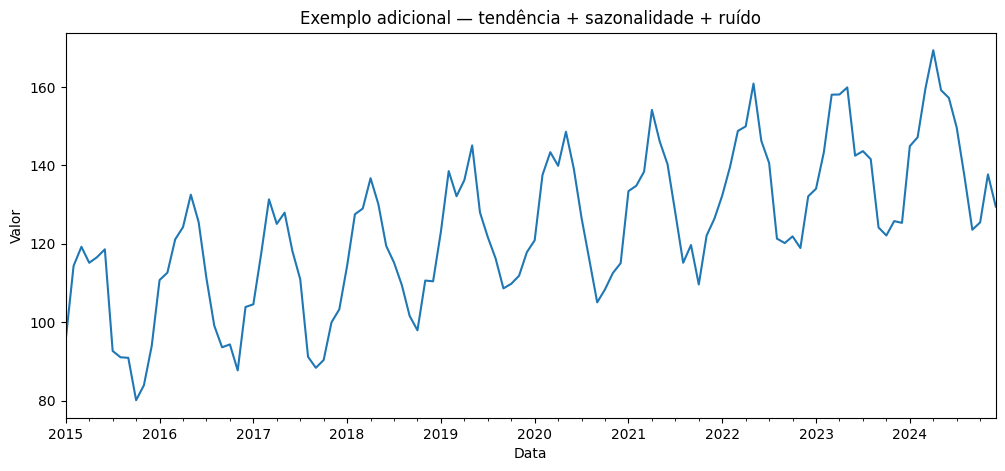

In [73]:
np.random.seed(123)

n = 120
datas = pd.date_range("2015-01-01", periods=n, freq="MS")

t = np.arange(n)
sazonalidade = 20 * np.sin(2 * np.pi * t / 12)
tendencia = 0.4 * t
ruido = np.random.normal(0, 4, n)

y_sazonal = 100 + tendencia + sazonalidade + ruido
serie_sazonal = pd.Series(y_sazonal, index=datas)

serie_sazonal.plot()
plt.title("Exemplo adicional — tendência + sazonalidade + ruído")
plt.xlabel("Data")
plt.ylabel("Valor")
plt.show()

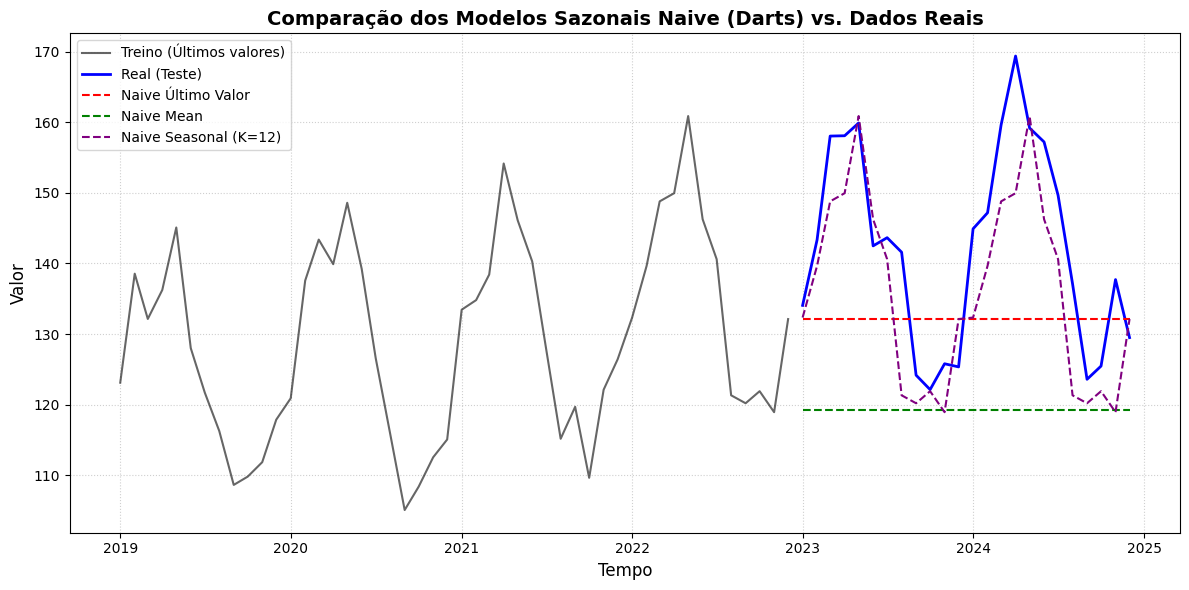

,Modelo,MAE,MSE,RMSE,MAPE (%),MPE (%),OPE (%)
0,Naive Seasonal (K=12),7.701467,94.088750,9.699936,5.318315,4.339222,-4.479625
1,Naive Último Valor,14.408461,300.232071,17.327206,9.637482,6.367720,-7.257044
2,Naive Mean,23.248118,733.820276,27.089117,15.516268,15.516268,-16.318699


In [74]:
# 1. Conversão para TimeSeries do Darts
if not isinstance(serie_sazonal, TimeSeries):
    series_s = TimeSeries.from_series(serie_sazonal)
else:
    series_s = serie_sazonal

# 2. Divisão em Treino e Teste
h = 24
train_s, test_s = series_s[:-h], series_s[-h:]

# 3. Definição e Ajuste dos Modelos com Darts
modelos_sazonal = {
    "Naive Último Valor": NaiveSeasonal(K=1),
    "Naive Mean": NaiveMean(),
    "Naive Seasonal (K=12)": NaiveSeasonal(K=12),  # Repete os últimos 12 períodos
}

preds_sazonal = {}

# 4. Treinamento e Predição
for nome, modelo in modelos_sazonal.items():
    modelo.fit(train_s)
    # Converte o retorno do Darts para vetor 1D NumPy
    preds_sazonal[nome] = modelo.predict(h).values().flatten()

# 5. Extração dos vetores e índices de tempo
y_test_array = test_s.values().flatten()
y_train_array = train_s.values().flatten()

index_treino = train_s.time_index
index_teste = test_s.time_index

# 6. Gráfico Comparativo
plt.figure(figsize=(12, 6))

# Plot dos dados reais (histórico recente e teste)
plt.plot(index_treino[-48:], y_train_array[-48:], label="Treino (Últimos valores)", color="black", alpha=0.6)
plt.plot(index_teste, y_test_array, label="Real (Teste)", color="blue", linewidth=2)

# Plot das Previsões
estilos = {
    "Naive Último Valor": "red",
    "Naive Mean": "green",
    "Naive Seasonal (K=12)": "purple"
}

for nome, pred in preds_sazonal.items():
    plt.plot(index_teste, pred, label=nome, linestyle="--", color=estilos.get(nome, "gray"))

plt.title("Comparação dos Modelos Sazonais Naive (Darts) vs. Dados Reais", fontsize=14, fontweight="bold")
plt.xlabel("Tempo", fontsize=12)
plt.ylabel("Valor", fontsize=12)
plt.legend(loc="best")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

plt.show()

# 7. Cálculo e Tabela de Métricas
resultados_s = []

for nome, pred in preds_sazonal.items():
    resultados_s.append({
        "Modelo": nome,
        "MAE": mae(y_test_array, pred),
        "MSE": mse(y_test_array, pred),
        "RMSE": rmse(y_test_array, pred),
        "MAPE (%)": mape(y_test_array, pred),
        "MPE (%)": mpe(y_test_array, pred),
        "OPE (%)": ope(y_test_array, pred),
    })

metricas_sazonal = (
    pd.DataFrame(resultados_s)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

metricas_sazonal

# 16. O que aprendemos com os exemplos?

Os exemplos ilustram uma ideia central de séries temporais:

> **A estrutura da série deve orientar a escolha do benchmark.**

- Séries sem estrutura clara podem ter benchmarks simples como média ou último valor como referência.
- Séries com tendência podem favorecer o Naive Drift.
- Séries sazonais podem ser melhor representadas pelo Naive Seasonal.
- A média móvel pode ser útil quando queremos suavizar oscilações recentes.

Isso não significa que esses benchmarks serão sempre os melhores. O ponto é estabelecer uma referência adequada antes de avaliar modelos mais sofisticados.

# 17. Exemplo aplicado — vendas de uma padaria

Agora vamos aplicar os conceitos de **benchmark** e **métricas de performance** a um problema de negócio: previsão diária de vendas de uma padaria.

A variável de interesse é `Vendas`, observada diariamente. Neste exemplo, a frequência diária permite investigar um comportamento sazonal muito comum em estabelecimentos comerciais: **diferenças entre os dias da semana**.

> **Importante:** o arquivo Excel será fornecido pelo professor/aluno. O código abaixo foi escrito para trabalhar com uma planilha contendo as colunas `Data` e `Vendas`.

A análise seguirá o fluxo:

**dados → exploração → treino/teste → benchmarks → previsões → métricas → comparação → interpretação**


Ao transformar `Data` em índice temporal, podemos:

- ordenar corretamente as observações;
- identificar a frequência da série;
- visualizar padrões ao longo do tempo;
- construir o conjunto de teste respeitando o futuro;
- explorar sazonalidade semanal.

In [75]:
ARQUIVO_PADARIA = "vendas_padaria.csv"

df_padaria = pd.read_csv(ARQUIVO_PADARIA, sep=None, engine="python")

# Conversão e tratamento das colunas
df_padaria["Data"] = pd.to_datetime(df_padaria["Data"], errors="coerce")
df_padaria["Vendas"] = pd.to_numeric(df_padaria["Vendas"], errors="coerce")

df_padaria.head()

,Data,Vendas
0,2024-02-04,52
1,2024-02-05,20
2,2024-02-06,34
3,2024-02-07,31
4,2024-02-08,36


## 17.2 Verificação da frequência diária

Como estamos trabalhando com vendas diárias, precisamos verificar se existem datas ausentes.

Essa etapa é importante porque um benchmark sazonal com período 7 pressupõe que a sequência represente corretamente os dias consecutivos da semana.

Se houver datas ausentes, **não devemos simplesmente ignorá-las sem discutir o significado da ausência**. Uma data sem registro pode representar venda zero, falha de coleta ou estabelecimento fechado.

In [76]:
datas_completas = pd.date_range(
    start=df_padaria.index.min(),
    end=df_padaria.index.max(),
    freq="D"
)

datas_ausentes = datas_completas.difference(df_padaria.index)

print(f"Datas ausentes: {len(datas_ausentes)}")
if len(datas_ausentes) > 0:
    print(datas_ausentes[:20])

df_padaria.describe()

Datas ausentes: 1
DatetimeIndex(['1970-01-01'], dtype='datetime64[ns]', freq='D')


,Data,Vendas
count,364,364.000000
mean,2024-08-03 12:00:00,45.310440
min,2024-02-04 00:00:00,20.000000
25%,2024-05-04 18:00:00,32.000000
50%,2024-08-03 12:00:00,41.000000
75%,2024-11-02 06:00:00,54.000000
max,2025-02-01 00:00:00,95.000000
std,NaN,16.308317


## 17.3 Visualização das vendas

Antes de escolher um benchmark, devemos olhar para a série.

Em previsão, a análise exploratória ajuda a formular hipóteses sobre o comportamento que um benchmark precisa capturar.

Para uma padaria, algumas perguntas são particularmente relevantes:

- existe tendência de crescimento ou queda?
- as vendas variam entre dias da semana?
- há períodos com comportamento atípico?
- a variabilidade parece constante?
- o padrão semanal se repete?

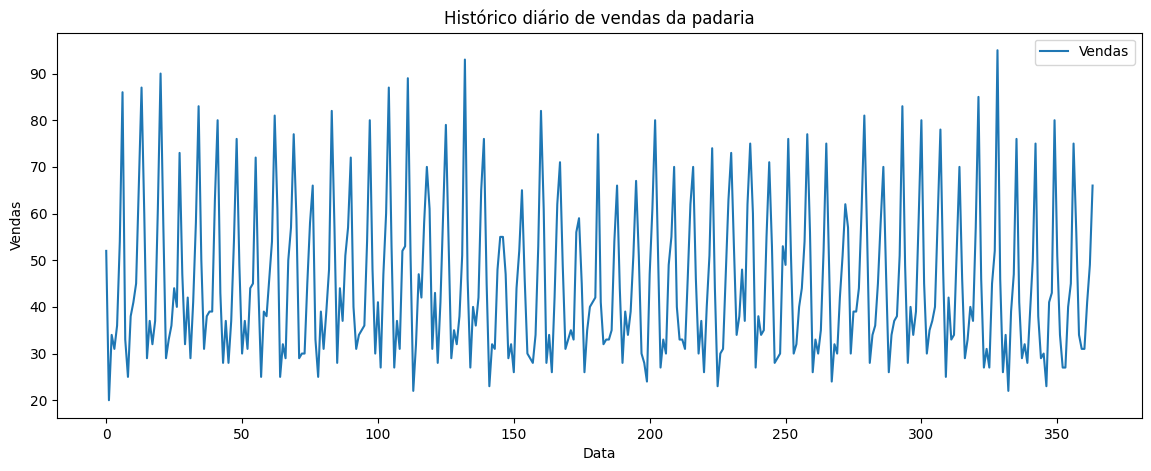

In [77]:
plt.figure(figsize=(14, 5))
plt.plot(df_padaria.index, df_padaria["Vendas"], label="Vendas")
plt.title("Histórico diário de vendas da padaria")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.show()

## 17.4 Sazonalidade semanal

Como a série é diária, um benchmark sazonal natural é o **período 7**.

O benchmark `Naive Seasonal` com `K=7` prevê para amanhã o valor observado sete dias atrás. Em outras palavras, a previsão para uma segunda-feira utiliza como referência a segunda-feira anterior.

Esse benchmark é especialmente útil quando o comportamento de vendas é influenciado pelo **dia da semana**.

Observe que identificar sazonalidade não significa automaticamente escolher um modelo sofisticado. Primeiro devemos verificar se uma regra simples baseada nesse padrão já produz previsões competitivas.

In [78]:
# 1. Garante que a coluna 'Data' esteja no formato datetime
#df_semana["Data"] = pd.to_datetime(df_semana["Data"])

# 2. Extrai o número do dia da semana (0 = Segunda, ..., 6 = Domingo)
df_semana["Dia_semana"] = df_semana["Data"].dt.dayofweek

ordem_dias = [0, 1, 2, 3, 4, 5, 6]
nomes_dias = {
    0: "Segunda", 1: "Terça", 2: "Quarta", 3: "Quinta",
    4: "Sexta", 5: "Sábado", 6: "Domingo"
}

# 3. Mapeia os números para o nome do dia em português
df_semana["Nome_Dia"] = df_semana["Dia_semana"].map(nomes_dias)

df_semana.head()

,Data,Vendas,Dia_semana,Nome_Dia
0,2024-02-04,52,6,Domingo
1,2024-02-05,20,0,Segunda
2,2024-02-06,34,1,Terça
3,2024-02-07,31,2,Quarta
4,2024-02-08,36,3,Quinta


In [79]:
perfil_semanal = (
    df_semana.groupby("Dia_semana")["Vendas"]
    .agg(["mean", "median", "std", "count"])
    .reindex(ordem_dias)
)
perfil_semanal.index = [nomes_dias[i] for i in perfil_semanal.index]
perfil_semanal

,mean,median,std,count
Segunda,28.211538,28.5,3.037908,52
Terça,34.884615,34.0,4.051888,52
Quarta,32.480769,31.0,5.546560,52
Quinta,41.634615,41.0,4.927032,52
Sexta,54.596154,54.0,5.948338,52
Sábado,76.115385,76.0,8.247766,52
Domingo,49.250000,49.0,6.862444,52


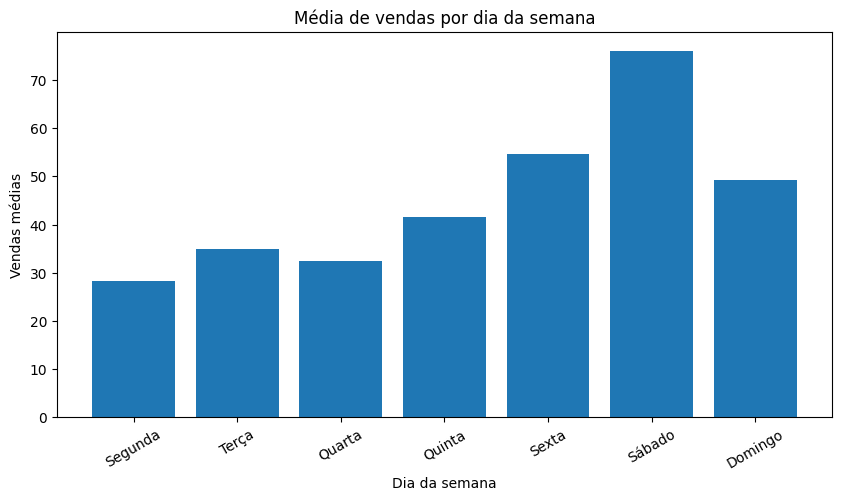

In [80]:
plt.figure(figsize=(10, 5))
plt.bar(perfil_semanal.index, perfil_semanal["mean"])
plt.title("Média de vendas por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Vendas médias")
plt.xticks(rotation=30)
plt.show()

## 17.5 Separação temporal entre treino e teste

Vamos reservar os últimos **28 dias** para teste, mantendo os quatro ciclos semanais completos.

Essa escolha permite avaliar o desempenho dos benchmarks em um horizonte de quatro semanas e evita uma divisão aleatória dos dados.

### Princípio fundamental

O conjunto de teste representa um futuro que o modelo não poderia conhecer no momento da previsão.

**Treino → previsão do futuro → comparação com o realizado**

O benchmark deve ser ajustado usando apenas o conjunto de treino.

In [81]:
horizon_padaria = 28

if len(df_padaria) <= horizon_padaria + 14:
    raise ValueError("A série precisa ter mais observações para usar um teste de 28 dias.")

train_padaria = df_padaria.iloc[:-horizon_padaria].copy()
test_padaria = df_padaria.iloc[-horizon_padaria:].copy()

# Acessa o menor e maior valor da coluna "Data"
print("Treino:", train_padaria["Data"].min().date(), "até", train_padaria["Data"].max().date())
print("Teste:", test_padaria["Data"].min().date(), "até", test_padaria["Data"].max().date())

Treino: 2024-02-04 até 2025-01-04
Teste: 2025-01-05 até 2025-02-01


## 17.6 Benchmarks para as vendas da padaria

Vamos comparar cinco estratégias:

1. **Naive Mean** — utiliza a média histórica do treino;
2. **Naive Último Valor** — repete a última venda observada;
3. **Naive Seasonal (7)** — repete o padrão da mesma posição na semana anterior;
4. **Naive Drift** — extrapola linearmente a variação média observada;
5. **Naive Moving Average** — utiliza a média das últimas observações.

A ideia pedagógica é importante: não estamos tentando encontrar imediatamente o modelo mais sofisticado. Estamos construindo **referências de dificuldade crescente**.

In [82]:
# Preparação das séries temporais
series_train = TimeSeries.from_dataframe(train_padaria, time_col="Data", value_cols="Vendas")
series_test = TimeSeries.from_dataframe(test_padaria, time_col="Data", value_cols="Vendas")

h = len(series_test)

# Função auxiliar para MPE (já que não há mpe nativo no darts.metrics)
def mpe_custom(series_true, series_pred):
    y_true = series_true.values().flatten()
    y_pred = series_pred.values().flatten()
    return np.mean((y_true - y_pred) / y_true) * 100

# 2. Definição dos Modelos
modelos = {
    "Naive Mean": NaiveMean(),
    "Naive Último Valor": NaiveSeasonal(K=1),
    "Naive Seasonal (7)": NaiveSeasonal(K=7),
    "Naive Drift": NaiveDrift(),
    "Naive Moving Average (7)": NaiveMovingAverage(input_chunk_length=7),
}

predicoes_darts = {}
resultados_metricas = []

# 3. Treinamento, Previsão e Métricas
for nome, modelo in modelos.items():
    modelo.fit(series_train)
    pred = modelo.predict(h)
    predicoes_darts[nome] = pred

    # Calculando as métricas corretamente
    resultados_metricas.append({
        "Modelo": nome,
        "MAE": mae(series_test, pred),
        "MSE": mse(series_test, pred),
        "RMSE": rmse(series_test, pred),
        "MAPE (%)": mape(series_test, pred),
        
    })

# 4. Gráfico Comparativo de Vendas
plt.figure(figsize=(14, 7))

# Plot do histórico recente de treino e do teste real
series_train[-30:].plot(label="Treino (Últimos 30 dias)", color="black", alpha=0.6)
series_test.plot(label="Real (Teste)", color="blue", linewidth=2.5)

# Plot das previsões geradas
estilos = {
    "Naive Mean": "green",
    "Naive Último Valor": "red",
    "Naive Seasonal (7)": "purple",
    "Naive Drift": "orange",
    "Naive Moving Average (7)": "brown",
}

for nome, pred in predicoes_darts.items():
    pred.plot(label=nome, linestyle="--", color=estilos.get(nome, "gray"))

plt.title("Comparação de Modelos Naive para Vendas da Padaria", fontsize=14, fontweight="bold")
plt.xlabel("Data", fontsize=12)
plt.ylabel("Vendas", fontsize=12)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

plt.show()

# 5. Tabela de Métricas Ordenada pelo RMSE
df_metricas = pd.DataFrame(resultados_metricas).sort_values("RMSE").reset_index(drop=True)
df_metricas

IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.
IndexError: Integer index out of range.


ValueError: setting an array element with a sequence. The requested array would exceed the maximum number of dimension of 64.

In [ ]:
# Cálculo das métricas para todos os benchmarks.
resultados_padaria = []

for nome, pred in predicoes_padaria.items():
    resultados_padaria.append({
        "Modelo": nome,
        "MAE": mae(y_test.values, pred),
        "MSE": mse(y_test.values, pred),
        "RMSE": rmse(y_test.values, pred),
        "MAPE (%)": mape(y_test.values, pred),
        "MPE (%)": mpe(y_test.values, pred),
        "OPE (%)": ope(y_test.values, pred),
    })

metricas_padaria = (
    pd.DataFrame(resultados_padaria)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

metricas_padaria

## 17.9 Qual benchmark é melhor?

Não existe uma regra dizendo que um benchmark sempre será superior aos demais.

A escolha depende da estrutura da série:

- se o nível recente é muito informativo, o **Naive Último Valor** pode ser competitivo;
- se existe sazonalidade semanal forte, o **Naive Seasonal (7)** é uma referência natural;
- se existe tendência aproximadamente linear, o **Naive Drift** pode ser útil;
- se há muito ruído e o nível recente oscila, uma **média móvel** pode reduzir a variabilidade da previsão;
- o **Naive Mean** é uma referência simples para avaliar se modelos mais sofisticados realmente aprendem algo além do nível médio.

O ponto central é: **o benchmark adequado depende do padrão que queremos preservar na previsão**.

## 17.10 Análise por dia da semana

Uma análise complementar é comparar o erro do benchmark sazonal ao longo dos dias da semana.

Isso ajuda a responder uma pergunta de negócio:

> O benchmark semanal erra igualmente em todos os dias ou existem dias específicos em que a previsão é mais difícil?

Esse tipo de análise mostra que uma métrica agregada pode esconder diferenças importantes dentro do período de previsão.

In [ ]:
# 1. Copia o dataframe de teste
analise_dia = test_padaria[["Data", "Vendas"]].copy()

# 2. Extrai o dia da semana a partir da coluna 'Data'
analise_dia["Dia_semana"] = pd.to_datetime(analise_dia["Data"]).dt.dayofweek

# 3. Resgata a previsão sazonal do Darts
analise_dia["Pred_Seasonal"] = predicoes_darts["Naive Seasonal (7)"].values().flatten()

# 4. Calcula o erro absoluto diário
analise_dia["Erro_Abs"] = np.abs(analise_dia["Vendas"] - analise_dia["Pred_Seasonal"])
analise_dia["Dia"] = analise_dia["Dia_semana"].map(nomes_dias)

# 5. Agrupa para calcular o erro médio por dia da semana
erro_por_dia = (
    analise_dia.groupby(["Dia_semana", "Dia"])["Erro_Abs"]
    .mean()
    .reset_index()
    .sort_values("Dia_semana")
    .drop(columns=["Dia_semana"]) # Remove a coluna numérica mantendo apenas o nome do dia
)

erro_por_dia

## 17.11 O benchmark como ponto de partida para modelos mais sofisticados

Imagine que, posteriormente, sejam ajustados modelos ARIMA, ETS, Prophet, árvores de decisão ou redes neurais para prever as vendas.

O benchmark da padaria continua sendo necessário.

A comparação deve responder:

**Modelo sofisticado → supera benchmark? → quanto? → em quais métricas? → com qual custo de complexidade?**

Se um modelo sofisticado não superar consistentemente o `Naive Seasonal (7)`, por exemplo, pode ser que ele não esteja capturando informação adicional relevante para a previsão.

Por isso, benchmarks funcionam como uma **linha de base científica e operacional** para o desenvolvimento de modelos de previsão.